# Cài thư viện

In [1]:
!pip install -q torchinfo

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight
from torchinfo import summary

from tqdm import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Load dữ liệu

Number of Samples: 109446\
Number of Categories: 5\
Sampling Frequency: 125Hz\
Data Source: Physionet's MIT-BIH Arrhythmia Dataset\
Classes: ['N': 0, 'S': 1, 'V': 2, 'F': 3, 'Q': 4]

In [2]:
train_dir = "/kaggle/input/heartbeat/mitbih_train.csv"
test_dir = "/kaggle/input/heartbeat/mitbih_test.csv"
MODEL_DIR = "/kaggle/working/"

In [3]:
train_df = pd.read_csv(train_dir,header=None)
test_df = pd.read_csv(test_dir,header=None)
train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
train_df[187].unique()

array([0., 1., 2., 3., 4.])

In [5]:
train_df[187]=train_df[187].astype(int)
equilibre=train_df[187].value_counts()
print(equilibre)

187
0    72471
4     6431
2     5788
1     2223
3      641
Name: count, dtype: int64


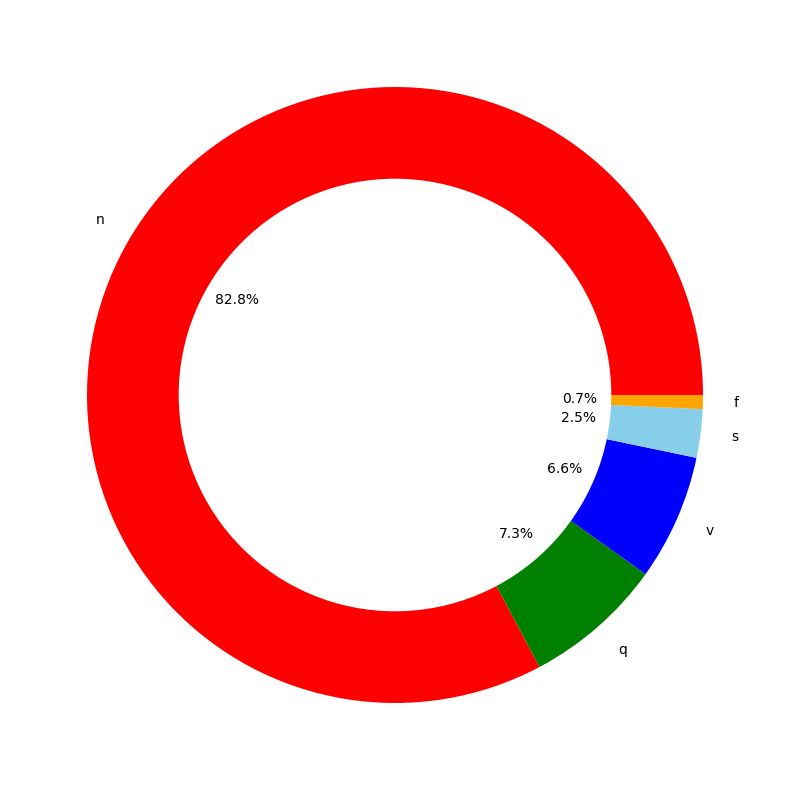

In [6]:
plt.figure(figsize=(20,10))
my_circle=plt.Circle( (0,0), 0.7, color='white')
plt.pie(equilibre, labels=['n','q','v','s','f'], colors=['red','green','blue','skyblue','orange'],autopct='%1.1f%%')
p=plt.gcf()
p.gca().add_artist(my_circle)
plt.show()

## Chia tập X, y

In [7]:
# X: 187 giá trị tín hiệu
X = train_df.iloc[:, :-1].values   # shape: (N, 187)
y = train_df.iloc[:, -1].values    # shape: (N,)
# split train / val
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y      # QUAN TRỌNG với ECG (imbalanced)
)

X_test  = test_df.iloc[:, :-1].values
y_test  = test_df.iloc[:, -1].values

In [8]:
# normalize từng sample (z-score)
def zscore_per_sample(X):
    return (X - X.mean(axis=1, keepdims=True)) / \
           (X.std(axis=1, keepdims=True) + 1e-8)

X_train = zscore_per_sample(X_train)
X_val   = zscore_per_sample(X_val)
X_test  = zscore_per_sample(X_test)

In [9]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

X_val   = torch.tensor(X_val,   dtype=torch.float32)
y_val   = torch.tensor(y_val,   dtype=torch.long)

X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_test  = torch.tensor(y_test,  dtype=torch.long)

In [10]:
train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val,   y_val)
test_dataset  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)


In [11]:
print(f"Len of train bath: {len(train_loader)}")
print(f"Len of val   bath: {len(val_loader)}")
print(f"Len of test  bath: {len(test_loader)}")

Len of train bath: 1094
Len of val   bath: 274
Len of test  bath: 343


In [12]:
x, y = next(iter(train_loader))
print(x.shape, y.shape)
# torch.Size([64, 187]) torch.Size([64])


torch.Size([64, 187]) torch.Size([64])


## Xử lý mất cân bằng

In [13]:
classes = np.unique(y_train.numpy())

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train.numpy()
)

class_weights = torch.tensor(class_weights, dtype=torch.float32)

In [14]:
class_weight_dict = dict(enumerate(class_weights))
class_weight_dict

{0: tensor(0.2416),
 1: tensor(7.8789),
 2: tensor(3.0256),
 3: tensor(27.3072),
 4: tensor(2.7228)}

# Mô hình

In [15]:
class ResidualBlock1D(nn.Module):
    def __init__(self, channels, kernel_size=5):
        super().__init__()
        padding = kernel_size // 2

        self.conv1 = nn.Conv1d(channels, channels, kernel_size, padding=padding)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size, padding=padding)
        self.conv3 = nn.Conv1d(channels, channels, kernel_size, padding=padding)

        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool1d(2)

    def forward(self, x):
        identity = self.pool(x)   # downsample skip path

        out = self.conv1(x)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.relu(out)
        out = self.conv3(out)

        out = self.pool(out)
        out = out + identity
        out = self.relu(out)

        return out


In [16]:
class ECG_CNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()

        # Input: (B, 1, 187)
        self.stem = nn.Conv1d(1, 32, kernel_size=5, padding=2)

        # 5 Residual Blocks
        self.res_blocks = nn.Sequential(
            ResidualBlock1D(32),
            ResidualBlock1D(32),
            ResidualBlock1D(32),
            ResidualBlock1D(32),
            ResidualBlock1D(32),
        )

        # Sau 5 lần pool: 187 → ~5
        self.fc1 = nn.Linear(32 * 5, 128)
        self.fc2 = nn.Linear(128, num_classes)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        # x: (B, 187)
        x = x.unsqueeze(1)          # (B, 1, 187)
        x = self.stem(x)            # (B, 32, 187)
        x = self.res_blocks(x)      # (B, 32, ~5)

        x = x.flatten(1)            # (B, 32*5)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x


## Xem kiến trúc mô hình

In [17]:
model = ECG_CNN(num_classes=5)

summary(
    model,
    input_size=(1, 187),  
    col_names=[
        "input_size",
        "output_size",
        "num_params",
        "kernel_size",
        "mult_adds"
    ],
    depth=3
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape              Mult-Adds
ECG_CNN                                  [1, 187]                  [1, 5]                    --                        --                        --
├─Conv1d: 1-1                            [1, 1, 187]               [1, 32, 187]              192                       [5]                       35,904
├─Sequential: 1-2                        [1, 32, 187]              [1, 32, 5]                --                        --                        --
│    └─ResidualBlock1D: 2-1              [1, 32, 187]              [1, 32, 93]               --                        --                        --
│    │    └─MaxPool1d: 3-1               [1, 32, 187]              [1, 32, 93]               --                        2                         --
│    │    └─Conv1d: 3-2                  [1, 32, 187]              [1, 32, 187]              5,152   

## Khai báo mô hình

In [18]:
model = ECG_CNN(num_classes=5).to(device)
criterion = torch.nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)
optimizer = torch.optim.AdamW(model.parameters(),
                              lr=1e-3,
                              weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

# Hàm train

In [19]:
def train_one_epoch(model,dataloader,optimizer,criterion,device,epoch):
    model.train()
    total_loss = 0.0

    pbar = tqdm(
        dataloader,
        desc=f"Epoch {epoch:03d} [Train]",
        leave=False
    )

    for signals, labels in pbar:
        # signals: (B, 187)
        # labels : (B,)
        signals = signals.to(device)
        labels  = labels.to(device)

        optimizer.zero_grad()

        logits = model(signals)      # (B, 5)
        loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        total_loss += loss.item()

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / len(dataloader)


In [20]:
@torch.no_grad()
def evaluate(model,dataloader,criterion,device):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    start_time = time.time()
    total_samples = 0

    for signals, labels in tqdm(dataloader, desc="Evaluate", leave=False):
        signals = signals.to(device)
        labels  = labels.to(device)

        logits = model(signals)
        loss = criterion(logits, labels)

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

        total_samples += signals.size(0)

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    metrics = {
        "loss": total_loss / len(dataloader),
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, average="macro", zero_division=0),
        "recall": recall_score(all_labels, all_preds, average="macro", zero_division=0),
        "inference_time": (time.time() - start_time) / total_samples
    }

    return metrics


## Early stopping

In [21]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best = float("inf")
        self.counter = 0
        self.stop = False

    def step(self, metric):
        if metric < self.best - self.min_delta:
            self.best = metric
            self.counter = 0
            return True   # improved
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
            return False

# Huấn luyện mô hình

In [22]:
ckpt = torch.load("/kaggle/input/cnn-3/pytorch/default/1/best_epoch_4_acc_0.1791.pth", map_location=device)

model.load_state_dict(ckpt["model_state"])
optimizer.load_state_dict(ckpt["optimizer_state"])
scheduler.load_state_dict(ckpt["scheduler_state"])

start_epoch = ckpt["epoch"] + 1
best_val_loss = ckpt["best_val_loss"]
history = ckpt["history"]

print(f"✔ Resume training from epoch {start_epoch}")


✔ Resume training from epoch 5


In [23]:
# NUM_EPOCHS = 100
# start_epoch = 1
# best_val_loss = float("inf")
# early_stopper = EarlyStopping(patience=10)

# history = []

# for epoch in range(start_epoch, NUM_EPOCHS + 1):

#     # -------- TRAIN --------
#     train_loss = train_one_epoch(model,train_loader,optimizer,criterion,device,epoch)

#     # -------- VALIDATE --------
#     val_metrics = evaluate(model,val_loader,criterion,device)

#     val_loss = val_metrics["loss"]

#     # -------- SCHEDULER --------
#     scheduler.step(val_loss)

#     print(
#         f"Epoch [{epoch:03d}/{NUM_EPOCHS}] | "
#         f"Train Loss: {train_loss:.4f} | "
#         f"Val Loss: {val_loss:.4f} | "
#         f"Acc: {val_metrics['accuracy']:.4f} | "
#         f"Prec: {val_metrics['precision']:.4f} | "
#         f"Recall: {val_metrics['recall']:.4f} | "
#         f"Infer: {val_metrics['inference_time']*1000:.2f} ms/sample"
#     )

#     history.append({
#         "epoch": epoch,
#         "train_loss": train_loss,
#         "val_loss": val_loss,
#         "accuracy": val_metrics["accuracy"],
#         "precision": val_metrics["precision"],
#         "recall": val_metrics["recall"],
#         "infer_time": val_metrics["inference_time"],
#         "lr": optimizer.param_groups[0]["lr"]
#     })

# # -------- EARLY STOPPING --------
#     improved = early_stopper.step(val_loss)

#     if improved:
#         best_val_loss = val_loss

#         ckpt_path = os.path.join(
#                 MODEL_DIR,
#                 f"best_epoch_{epoch}_acc_{val_loss:.4f}.pth"
#             )

#         torch.save({
#             "epoch": epoch,
#             "model_state": model.state_dict(),
#             "optimizer_state": optimizer.state_dict(),
#             "scheduler_state": scheduler.state_dict(),
#             "best_val_loss": best_val_loss,
#             "history": history
#         }, ckpt_path)

#         print("→ Saved full checkpoint (best validation loss)")

#     if early_stopper.stop:
#         print("Early stopping triggered")
#         break


# Test

In [24]:
@torch.no_grad()
def test(model,dataloader,device):
    model.eval()

    all_preds = []
    all_labels = []

    start_time = time.time()
    total_samples = 0

    for signals, labels in tqdm(dataloader, desc="Test", leave=False):
        signals = signals.to(device)
        labels  = labels.to(device)

        logits = model(signals)            # (B, 5)
        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

        total_samples += signals.size(0)

    end_time = time.time()

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    results = {
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, average="macro", zero_division=0),
        "recall": recall_score(all_labels, all_preds, average="macro", zero_division=0),
        "inference_time": (end_time - start_time) / total_samples
    }

    return results


test_metrics = test(
    model,
    test_loader,
    device
)

print(
    f"TEST RESULTS | "
    f"Acc: {test_metrics['accuracy']:.4f} | "
    f"Prec: {test_metrics['precision']:.4f} | "
    f"Recall: {test_metrics['recall']:.4f} | "
    f"Infer: {test_metrics['inference_time']*1000:.2f} ms/sample"
)

TEST RESULTS | Acc: 0.9365 | Prec: 0.7065 | Recall: 0.9248 | Infer: 0.04 ms/sample


# Huấn luyện mô hình với 2 lớp

In [45]:
# Load data
normal = pd.read_csv("/kaggle/input/heartbeat/ptbdb_normal.csv", header=None)
abnormal = pd.read_csv("/kaggle/input/heartbeat/ptbdb_abnormal.csv", header=None)

# Gán label
normal["label"] = 0
abnormal["label"] = 1

# Gộp lại
data = pd.concat([normal, abnormal], axis=0)\
         .sample(frac=1, random_state=42)\
         .reset_index(drop=True)

X = data.iloc[:, :-1].values   # ECG signal
y = data["label"].values       # 0 / 1

In [46]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,        
    stratify=y,
    random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,        # chia đôi 30% → 15% + 15%
    stratify=y_temp,
    random_state=42
)

In [47]:
print(np.bincount(y_train))
print(np.bincount(y_val))
print(np.bincount(y_test))


[2832 7354]
[ 607 1576]
[ 607 1576]


In [48]:
# normalize từng sample (z-score)
X_train = zscore_per_sample(X_train)
X_val   = zscore_per_sample(X_val)
X_test  = zscore_per_sample(X_test)

In [49]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

X_val   = torch.tensor(X_val,   dtype=torch.float32)
y_val   = torch.tensor(y_val,   dtype=torch.long)

X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_test  = torch.tensor(y_test,  dtype=torch.long)

In [50]:
train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val,   y_val)
test_dataset  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print(f"Len of train bath: {len(train_loader)}")
print(f"Len of val   bath: {len(val_loader)}")
print(f"Len of test  bath: {len(test_loader)}")

Len of train bath: 159
Len of val   bath: 35
Len of test  bath: 35


In [51]:
classes = np.unique(y_train.numpy())

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train.numpy()
)

class_weights = torch.tensor(class_weights, dtype=torch.float32)
class_weight_dict = dict(enumerate(class_weights))
class_weight_dict

{0: tensor(1.7984), 1: tensor(0.6925)}

In [52]:
model_2class = ECG_CNN(num_classes=5)
model_2class.load_state_dict(ckpt["model_state"])

model_2class.fc2 = nn.Linear(128, 2)


In [53]:
for param in model_2class.stem.parameters():
    param.requires_grad = False

for param in model_2class.res_blocks.parameters():
    param.requires_grad = False

for param in model_2class.fc1.parameters():
    param.requires_grad = False

In [54]:
criterion = torch.nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)
optimizer = torch.optim.AdamW(model.parameters(),
                              lr=1e-3,
                              weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)
model_2class = model_2class.to(device)

In [55]:
NUM_EPOCHS = 50
start_epoch = 1
best_val_loss = float("inf")
early_stopper = EarlyStopping(patience=10)

history = []

for epoch in range(start_epoch, NUM_EPOCHS + 1):

    # -------- TRAIN --------
    train_loss = train_one_epoch(model_2class,train_loader,optimizer,criterion,device,epoch)

    # -------- VALIDATE --------
    val_metrics = evaluate(model_2class,val_loader,criterion,device)

    val_loss = val_metrics["loss"]

    # -------- SCHEDULER --------
    scheduler.step(val_loss)

    print(
        f"Epoch [{epoch:03d}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Acc: {val_metrics['accuracy']:.4f} | "
        f"Prec: {val_metrics['precision']:.4f} | "
        f"Recall: {val_metrics['recall']:.4f} | "
        f"Infer: {val_metrics['inference_time']*1000:.2f} ms/sample"
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "accuracy": val_metrics["accuracy"],
        "precision": val_metrics["precision"],
        "recall": val_metrics["recall"],
        "infer_time": val_metrics["inference_time"],
        "lr": optimizer.param_groups[0]["lr"]
    })

# -------- EARLY STOPPING --------
    improved = early_stopper.step(val_loss)

    if improved:
        best_val_loss = val_loss

        ckpt_path = os.path.join(
                MODEL_DIR,
                f"best_epoch_{epoch}_acc_{val_loss:.4f}.pth"
            )

        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "best_val_loss": best_val_loss,
            "history": history
        }, ckpt_path)

        print("→ Saved full checkpoint (best validation loss)")

    if early_stopper.stop:
        print("Early stopping triggered")
        break


Epoch [001/50] | Train Loss: 0.8234 | Val Loss: 0.8142 | Acc: 0.6569 | Prec: 0.5024 | Recall: 0.5015 | Infer: 0.05 ms/sample
→ Saved full checkpoint (best validation loss)


Epoch [002/50] | Train Loss: 0.8240 | Val Loss: 0.8142 | Acc: 0.6569 | Prec: 0.5024 | Recall: 0.5015 | Infer: 0.04 ms/sample


Epoch [003/50] | Train Loss: 0.8237 | Val Loss: 0.8142 | Acc: 0.6569 | Prec: 0.5024 | Recall: 0.5015 | Infer: 0.04 ms/sample


Epoch [004/50] | Train Loss: 0.8229 | Val Loss: 0.8142 | Acc: 0.6569 | Prec: 0.5024 | Recall: 0.5015 | Infer: 0.04 ms/sample


Epoch [005/50] | Train Loss: 0.8233 | Val Loss: 0.8142 | Acc: 0.6569 | Prec: 0.5024 | Recall: 0.5015 | Infer: 0.04 ms/sample


...

Epoch [007/50] | Train Loss: 0.8234 | Val Loss: 0.8142 | Acc: 0.6569 | Prec: 0.5024 | Recall: 0.5015 | Infer: 0.04 ms/sample


Epoch [008/50] | Train Loss: 0.8226 | Val Loss: 0.8142 | Acc: 0.6569 | Prec: 0.5024 | Recall: 0.5015 | Infer: 0.04 ms/sample


Epoch [009/50] | Train Loss: 0.8226 | Val Loss: 0.8142 | Acc: 0.6569 | Prec: 0.5024 | Recall: 0.5015 | Infer: 0.04 ms/sample


Epoch [010/50] | Train Loss: 0.8225 | Val Loss: 0.8142 | Acc: 0.6569 | Prec: 0.5024 | Recall: 0.5015 | Infer: 0.04 ms/sample


Epoch [011/50] | Train Loss: 0.8234 | Val Loss: 0.8142 | Acc: 0.6569 | Prec: 0.5024 | Recall: 0.5015 | Infer: 0.04 ms/sample
Early stopping triggered


In [56]:
@torch.no_grad()
def test(model,dataloader,device):
    model.eval()

    all_preds = []
    all_labels = []

    start_time = time.time()
    total_samples = 0

    for signals, labels in tqdm(dataloader, desc="Test", leave=False):
        signals = signals.to(device)
        labels  = labels.to(device)

        logits = model(signals)            # (B, 5)
        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

        total_samples += signals.size(0)

    end_time = time.time()

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    from sklearn.metrics import confusion_matrix
    print(confusion_matrix(all_labels, all_preds))
    results = {
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, average="macro", zero_division=0),
        "recall": recall_score(all_labels, all_preds, average="macro", zero_division=0),
        "inference_time": (end_time - start_time) / total_samples
    }

    return results


test_metrics = test(
    model_2class,
    test_loader,
    device
)

print(
    f"TEST RESULTS | "
    f"Acc: {test_metrics['accuracy']:.4f} | "
    f"Prec: {test_metrics['precision']:.4f} | "
    f"Recall: {test_metrics['recall']:.4f} | "
    f"Infer: {test_metrics['inference_time']*1000:.2f} ms/sample"
)

[[  83  524]
 [ 238 1338]]
TEST RESULTS | Acc: 0.6509 | Prec: 0.4886 | Recall: 0.4929 | Infer: 0.04 ms/sample
